In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

In [ ]:


# 1. Cargar los datos preprocesados
train = pd.read_csv('processed/train.csv')
test = pd.read_csv('processed/test.csv')

# Separar variables independientes (X) y la variable objetivo (y)
X_train = train.drop(columns=['MERMA_Kg'])
y_train = train['MERMA_Kg']

X_test = test.drop(columns=['MERMA_Kg'])
y_test = test['MERMA_Kg']

# 2. Ingeniería de Fechas
# Convertir a formato fecha y extraer el día de la semana (0=Lunes, 6=Domingo)
X_train['fecha'] = pd.to_datetime(X_train['fecha'], format='%d/%m/%Y')
X_test['fecha'] = pd.to_datetime(X_test['fecha'], format='%d/%m/%Y')

X_train['dia_semana'] = X_train['fecha'].dt.dayofweek
X_test['dia_semana'] = X_test['fecha'].dt.dayofweek

# Eliminamos la columna original de fecha
X_train = X_train.drop(columns=['fecha'])
X_test = X_test.drop(columns=['fecha'])

# 3. Imputación de Valores Nulos
# Llenamos los vacíos con la mediana calculada estrictamente sobre el set de entrenamiento
for col in ['gramaje', 'ancho']:
    mediana_train = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana_train)
    X_test[col] = X_test[col].fillna(mediana_train)

# 4. Codificación de Variables Categóricas (One-Hot Encoding)
cols_cat = ['turno', 'categoria', 'maquina']
# drop_first=True evita la multicolinealidad perfecta (ideal para modelos de regresión)
X_train_encoded = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 5. Escalamiento de Variables Numéricas
cols_num = ['gramaje', 'ancho', 'peso_kg', 'metros_lineales', 'dia_semana']
scaler = StandardScaler()

# Entrenamos el escalador en train y transformamos ambos
X_train_encoded[cols_num] = scaler.fit_transform(X_train_encoded[cols_num])
X_test_encoded[cols_num] = scaler.transform(X_test_encoded[cols_num])

print("¡Ingeniería de características completada con éxito!")
print(f"Forma final de X_train: {X_train_encoded.shape}")
print(f"Forma final de X_test: {X_test_encoded.shape}")

¡Ingeniería de características completada con éxito!
Forma final de X_train: (213, 15)
Forma final de X_test: (54, 15)


In [4]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento preparados
modelo_rf.fit(X_train_encoded, y_train)

# 3. Generar predicciones con los datos de prueba (test)
predicciones = modelo_rf.predict(X_test_encoded)

# 4. Calcular métricas de evaluación
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print("=== Evaluación del Modelo de Regresión (Random Forest) ===")
print(f"Error Absoluto Medio (MAE): {mae:.2f} kg")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} kg")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

=== Evaluación del Modelo de Regresión (Random Forest) ===
Error Absoluto Medio (MAE): 11.07 kg
Raíz del Error Cuadrático Medio (RMSE): 13.52 kg
Coeficiente de Determinación (R2): 0.1988


=== Comparativa: Entrenamiento vs Prueba ===
MAE  - Train: 3.79 kg | Test: 11.07 kg
RMSE - Train: 5.07 kg | Test: 13.52 kg
R2   - Train: 0.8810  | Test: 0.1988


C:\Users\dguer\AppData\Local\Temp\ipykernel_33144\430215742.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia, x='Importancia', y='Variable', ax=axes[1], palette='viridis')


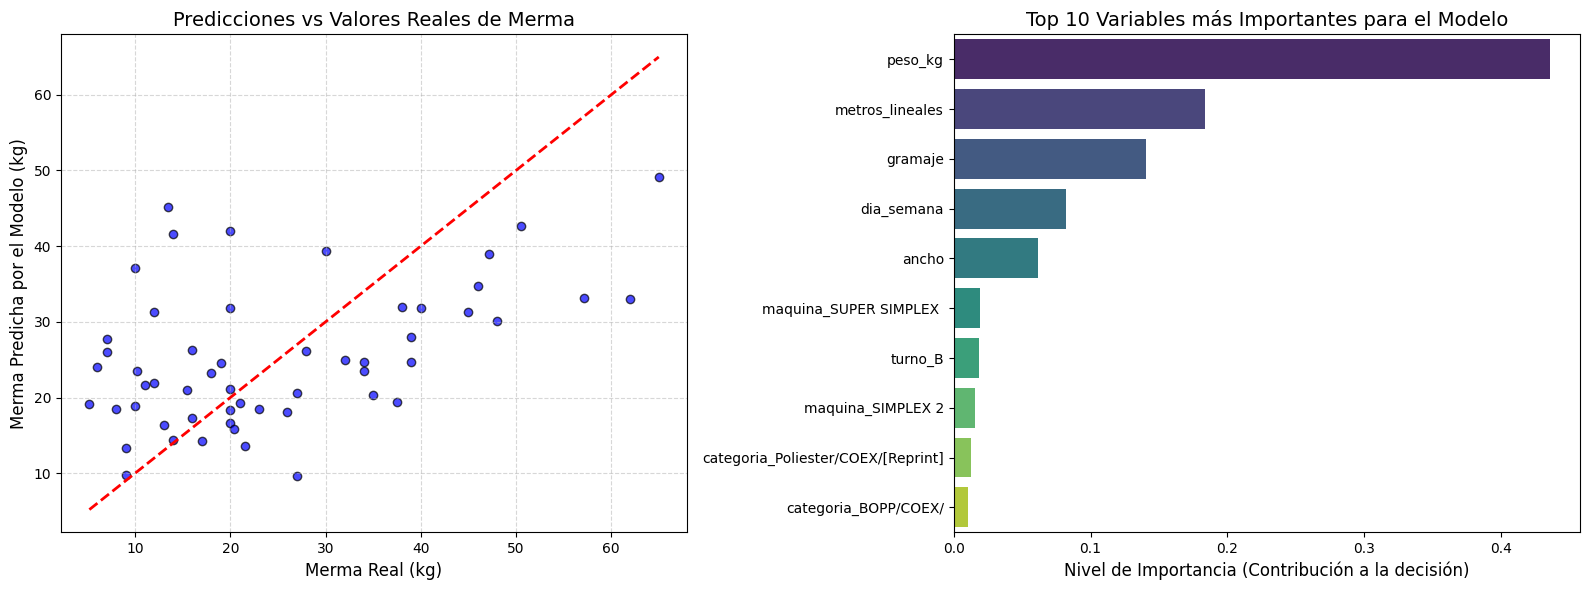

In [ ]:
predicciones_train = modelo_rf.predict(X_train_encoded)
predicciones_test = modelo_rf.predict(X_test_encoded) 

# 2. Calcular métricas para el conjunto de ENTRENAMIENTO
mae_train = mean_absolute_error(y_train, predicciones_train)
rmse_train = np.sqrt(mean_squared_error(y_train, predicciones_train))
r2_train = r2_score(y_train, predicciones_train)

# 3. Calcular métricas para el conjunto de PRUEBA (Test)
mae_test = mean_absolute_error(y_test, predicciones_test)
rmse_test = np.sqrt(mean_squared_error(y_test, predicciones_test))
r2_test = r2_score(y_test, predicciones_test)

# Mostrar comparativa
print("=== Comparativa: Entrenamiento vs Prueba ===")
print(f"MAE  - Train: {mae_train:.2f} kg | Test: {mae_test:.2f} kg")
print(f"RMSE - Train: {rmse_train:.2f} kg | Test: {rmse_test:.2f} kg")
print(f"R2   - Train: {r2_train:.4f}  | Test: {r2_test:.4f}")


# SECCIÓN DE GRÁFICAS PARA EXPLICAR EL MODELO

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Valores Reales vs Predicciones (Set de Prueba)
axes[0].scatter(y_test, predicciones_test, alpha=0.7, color='blue', edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Línea ideal
axes[0].set_title('Predicciones vs Valores Reales de Merma', fontsize=14)
axes[0].set_xlabel('Merma Real (kg)', fontsize=12)
axes[0].set_ylabel('Merma Predicha por el Modelo (kg)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfica 2: Importancia de las Variables (Feature Importance)
# Extraer la importancia que el Random Forest le dio a cada columna
importancias = modelo_rf.feature_importances_
nombres_variables = X_train_encoded.columns

# Crear un DataFrame para ordenar los datos
df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10) # Top 10

sns.barplot(data=df_importancia, x='Importancia', y='Variable', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Variables más Importantes para el Modelo', fontsize=14)
axes[1].set_xlabel('Nivel de Importancia (Contribución a la decisión)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:

# 1. Definimos las "reglas" o límites que queremos probar
parametros_grid = {
    'n_estimators': [100, 200],          # Cantidad de árboles en el bosque
    'max_depth': [3, 5, 7],              # Profundidad máxima (para evitar que memorice)
    'min_samples_split': [5, 10, 15],    # Mínimo de datos para dividir una rama
    'min_samples_leaf': [2, 5, 10]       # Mínimo de datos en la decisión final
}

# 2. Inicializamos el modelo base
rf_base = RandomForestRegressor(random_state=42)

# 3. Configuramos la búsqueda automática (GridSearch)
# cv=5 significa Validación Cruzada (divide los datos de train en 5 partes para validarse a sí mismo)
busqueda = GridSearchCV(estimator=rf_base, param_grid=parametros_grid, 
                        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

# 4. Entrenamos la búsqueda 
busqueda.fit(X_train_encoded, y_train)
modelo_optimizado = busqueda.best_estimator_

print(f"Mejores parámetros encontrados para evitar el overfitting:\n{busqueda.best_params_}\n")

# ==========================================
# EVALUAMOS EL NUEVO MODELO OPTIMIZADO
# ==========================================

# Predicciones
pred_train_opt = modelo_optimizado.predict(X_train_encoded)
pred_test_opt = modelo_optimizado.predict(X_test_encoded)

# Métricas Train
mae_train_opt = mean_absolute_error(y_train, pred_train_opt)
r2_train_opt = r2_score(y_train, pred_train_opt)

# Métricas Test
mae_test_opt = mean_absolute_error(y_test, pred_test_opt)
r2_test_opt = r2_score(y_test, pred_test_opt)

print("=== NUEVA Comparativa: Entrenamiento vs Prueba (Modelo Optimizado) ===")
print(f"MAE  - Train: {mae_train_opt:.2f} kg | Test: {mae_test_opt:.2f} kg")
print(f"R2   - Train: {r2_train_opt:.4f}  | Test: {r2_test_opt:.4f}")

Mejores parámetros encontrados para evitar el overfitting:
{'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

=== NUEVA Comparativa: Entrenamiento vs Prueba (Modelo Optimizado) ===
MAE  - Train: 6.65 kg | Test: 11.03 kg
R2   - Train: 0.6378  | Test: 0.2090
